In [19]:
# importing libraries 
from gettext import install
import sys
import random
import platform
from pathlib import Path
from itertools import combinations

import ipykernel
import numpy as np
import pandas as pd
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def main() -> None:
    print("Python:", sys.version.split()[0])
    print("Platform:", platform.platform())
    print("NumPy:", np.__version__)
    print("Pandas:", pd.__version__)

if __name__ == "__main__":
    main()

Python: 3.12.1
Platform: Linux-6.8.0-1044-azure-x86_64-with-glibc2.39
NumPy: 2.4.2
Pandas: 3.0.1


In [20]:
# Creating Project Structure 

PROJECT_ROOT   = Path.cwd() / "Deep Neural Network"
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_INTERIM   = PROJECT_ROOT / "data" / "interim"
REPORTS        = PROJECT_ROOT / "reports"
CONFIGS        = PROJECT_ROOT / "configs"
MODELS         = PROJECT_ROOT / "models"

for p in [ DATA_RAW, DATA_PROCESSED, DATA_INTERIM, REPORTS, CONFIGS, MODELS]:
    p.mkdir(parents=True, exist_ok=True)
    print(f" Created: {p.relative_to(PROJECT_ROOT)}")

print(f"\n  Project root: {PROJECT_ROOT}")
print(f"   Status: {'Ready' if PROJECT_ROOT.exists() else 'Failed'}")


 Created: data/raw
 Created: data/processed
 Created: data/interim
 Created: reports
 Created: configs
 Created: models

  Project root: /workspaces/DATA_SCIENCE-ELTE-/Deep Neural Network Class_ SEMI/Deep Neural Network
   Status: Ready


In [21]:
# writing readme file 
readme     = """ # Data Mining Homework 1

"""
(PROJECT_ROOT / 'README.md').write_text(readme)
print("Wrote :", PROJECT_ROOT / 'README.md')


Wrote : /workspaces/DATA_SCIENCE-ELTE-/Deep Neural Network Class_ SEMI/Deep Neural Network/README.md


In [22]:
# writing requirements file 

requirements = [
    f"NumPy=={np.__version__}",
    f"Pandas=={pd.__version__}",
    "openpyxl",    # spelling correction if needed
    "xlrd"          # needed this step for reading .xls files with pandas
]
(PROJECT_ROOT / "REQUIREMENTS.txt").write_text("\n".join(requirements)+"\n")
print("Wrote :" , PROJECT_ROOT / "REQUIREMENTS.txt")

# random control
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
np.random.random(6)


Wrote : /workspaces/DATA_SCIENCE-ELTE-/Deep Neural Network Class_ SEMI/Deep Neural Network/REQUIREMENTS.txt


array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
       0.15599452])

In [23]:
# writing configs file 

configs = { 
    "seed": SEED,
    "data": {
        "raw": str(DATA_RAW),
        "processed": str(DATA_PROCESSED),
        "interim": str(DATA_INTERIM)
    },
    "reports": str(REPORTS),
    "configs": str(CONFIGS),
    "models": str(MODELS)       
}

In [24]:
# importing json 
import json
(CONFIGS / "config.json").write_text(json.dumps(configs, indent=4))
print(f"Config written: {CONFIGS / 'config.json'}")

# Reading the dataset file by fetching the dataset directly from UCI Machine Learning Repository using the ucimlrepo package
from ucimlrepo import fetch_ucirepo
dataset = fetch_ucirepo("iris")
print(dataset)

# Basic ML Work Flow 
# Step 1 - Data Preparation including data cleaning, feature engineering, and data splitting
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

X = dataset.data.features
y = dataset.data.targets.values.ravel()  # Convert to NumPy array for consistency

print(X.head())
print(y[:5])  # Print first 5 for array
print(f"X: {X.shape}") 
print(f"y: {y.shape}")

Config written: /workspaces/DATA_SCIENCE-ELTE-/Deep Neural Network Class_ SEMI/Deep Neural Network/configs/config.json


{'data': {'ids': None, 'features':      sepal length  sepal width  petal length  petal width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns], 'targets':               class
0       Iris-setosa
1       Iris-setosa
2       Iris-setosa
3       Iris-setosa
4       Iris-setosa
..              ...
145  Iris-virginica
146  Iris-virginica
147  Iris-virginica
148  Iris-virginica
149  Iris-vir

In [25]:

# Step 1.1 - Data cleaning - checking the missing value 
print(X.isnull().sum())

# checking the value counts of the target variable
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

# Descriptive statistics of the dataset
print(X.describe())

# Data visualization 
# Create a combined DataFrame for plotting
df = X.copy()
df['class'] = y

sepal length    0
sepal width     0
petal length    0
petal width     0
dtype: int64
{'Iris-setosa': np.int64(50), 'Iris-versicolor': np.int64(50), 'Iris-virginica': np.int64(50)}
       sepal length  sepal width  petal length  petal width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


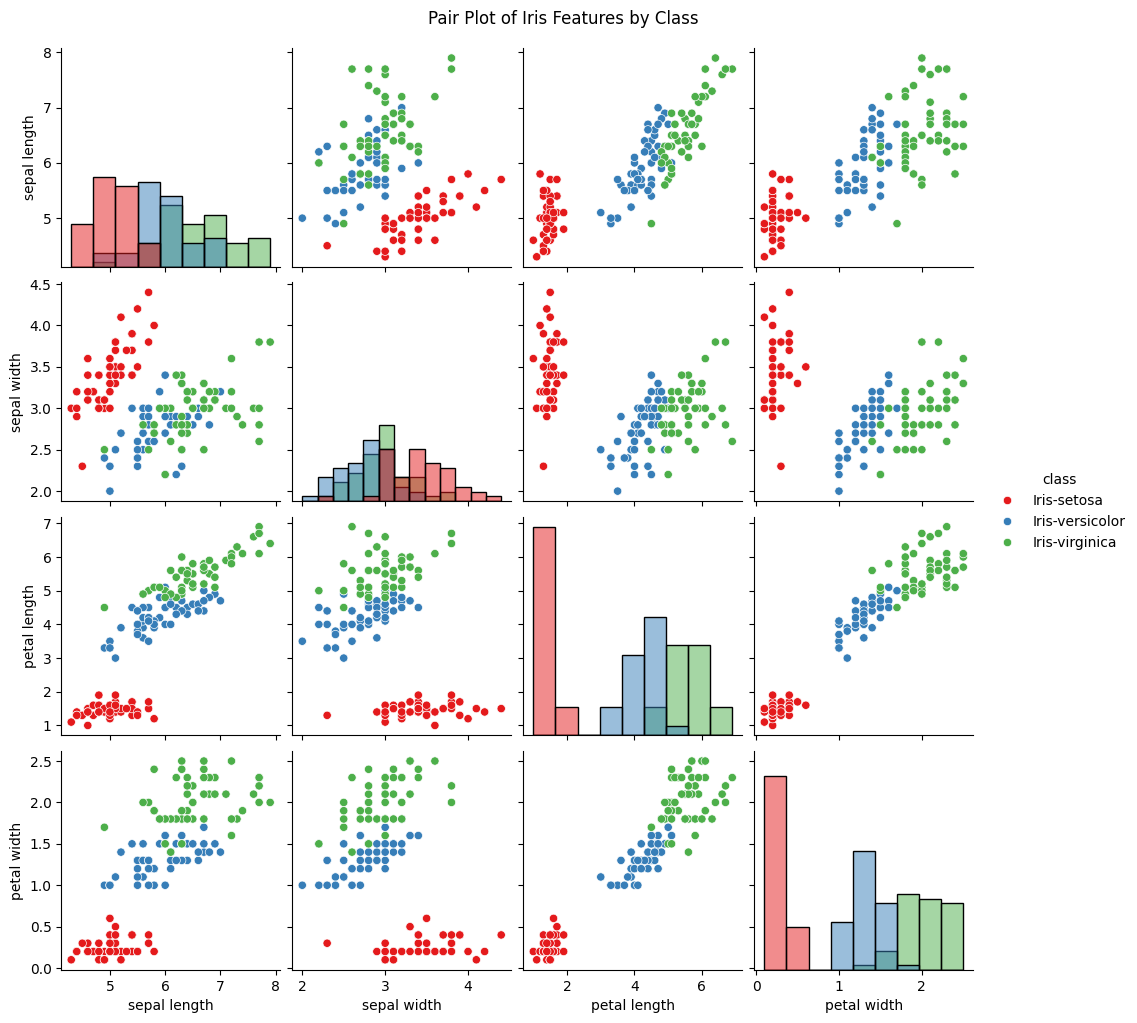

In [26]:
# Pair plot to visualize feature relationships and class separability
sns.pairplot(df, hue='class', diag_kind='hist', palette='Set1')
plt.suptitle('Pair Plot of Iris Features by Class', y=1.02)
plt.savefig(REPORTS / 'iris_pairplot.png')  # Save plot
# plt.show() 


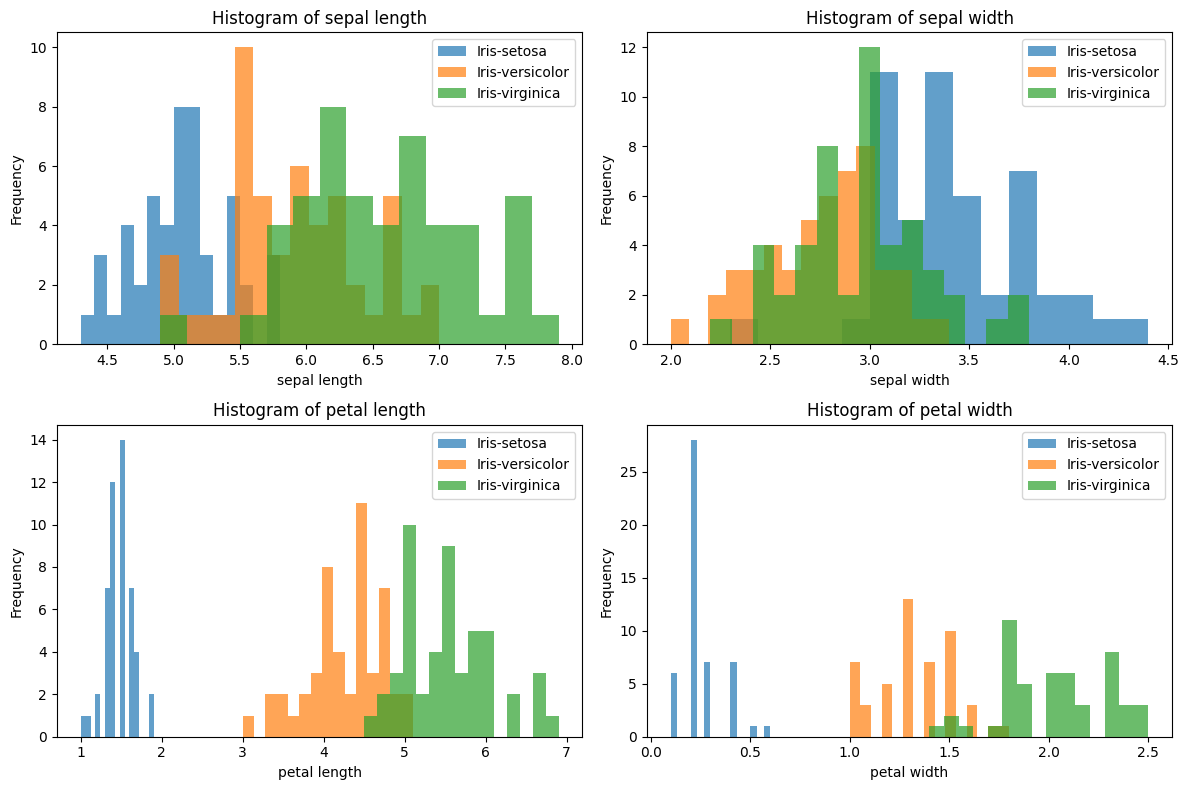

In [27]:
# Histograms for each feature to understand distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = X.columns
for i, feature in enumerate(features):
    ax = axes[i//2, i%2]
    for class_name in np.unique(y):
        subset = X[y == class_name][feature]
        ax.hist(subset, alpha=0.7, label=class_name, bins=15)
    ax.set_title(f'Histogram of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / 'iris_histograms.png') 
# plt.show()  


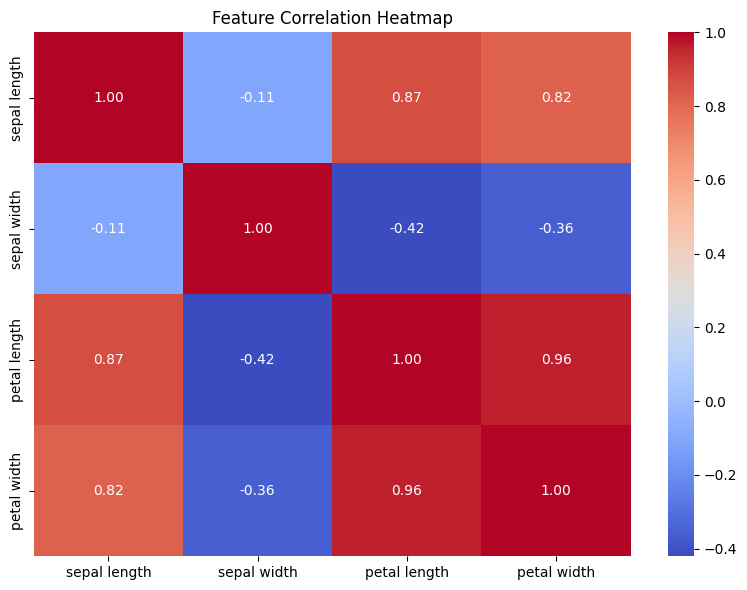

In [28]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(REPORTS / 'correlation_heatmap.png')
plt.show()

/tmp/ipykernel_87377/4125094512.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X[feature], palette='Set1')
/tmp/ipykernel_87377/4125094512.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X[feature], palette='Set1')
/tmp/ipykernel_87377/4125094512.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X[feature], palette='Set1')
/tmp/ipykernel_87377/4125094512.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

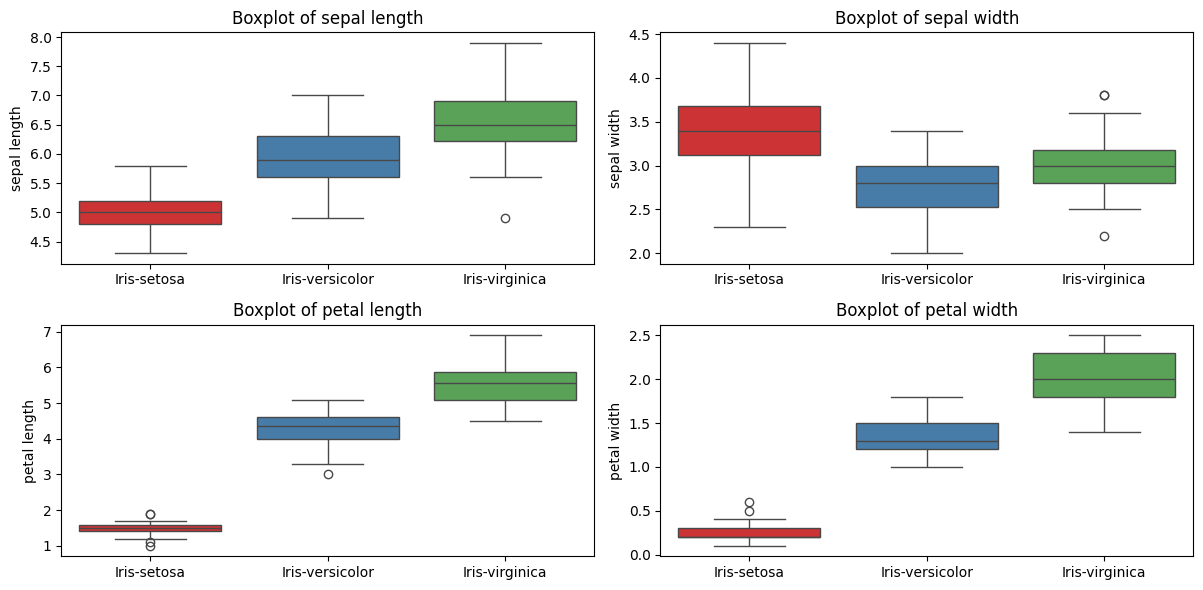

/tmp/ipykernel_87377/4125094512.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set1')


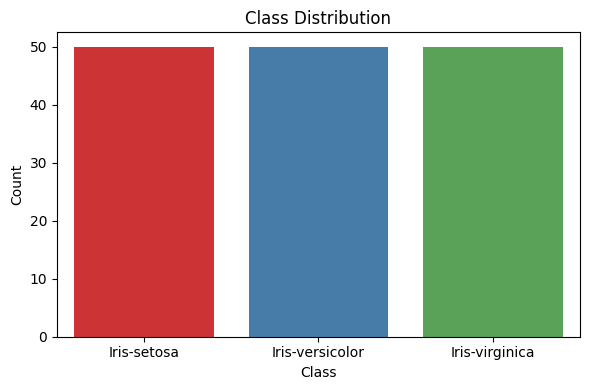

Visualizations saved to reports folder.


In [29]:
# Boxplot per class
plt.figure(figsize=(12, 6))
for i, feature in enumerate(X.columns[:4], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=y, y=X[feature], palette='Set1')
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.savefig(REPORTS / 'boxplots.png')
plt.show()

# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set1')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(REPORTS / 'class_distribution.png')
plt.show()

print("Visualizations saved to reports folder.")

In [30]:
# Step 1.2 - Feature scaling and creating new features by combining existing features

# Create new features (e.g., petal area as an example of feature engineering)
X['petal_area'] = X['petal length'] * X['petal width']

# Feature scaling using StandardScaler (standardizes to mean=0, std=1 which always to use when doing feature scalling step)
# Note: StandardScaler is used to standardize the features by removing the mean and scaling to unit variance. This is important for many machine learning algorithms that are sensitive to the scale of the data, such as gradient descent-based algorithms and distance-based algorithms.
# StandardScaler is a common choice for feature scaling because it centers the data around zero and scales it to have a standard deviation of one, which can help improve the performance of our ML Model.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("New features added and scaled data:")
print(X_scaled.head())
print(X_scaled.describe())


New features added and scaled data:
   sepal length  sepal width  petal length  petal width  petal_area
0     -0.900681     1.032057     -1.341272    -1.312977   -1.173566
1     -1.143017    -0.124958     -1.341272    -1.312977   -1.173566
2     -1.385353     0.337848     -1.398138    -1.312977   -1.177823
3     -1.506521     0.106445     -1.284407    -1.312977   -1.169309
4     -1.021849     1.263460     -1.341272    -1.312977   -1.173566
       sepal length   sepal width  petal length   petal width  petal_area
count  1.500000e+02  1.500000e+02  1.500000e+02  1.500000e+02  150.000000
mean  -4.736952e-16 -6.631732e-16  3.315866e-16 -2.842171e-16    0.000000
std    1.003350e+00  1.003350e+00  1.003350e+00  1.003350e+00    1.003350
min   -1.870024e+00 -2.438987e+00 -1.568735e+00 -1.444450e+00   -1.209754
25%   -9.006812e-01 -5.877635e-01 -1.227541e+00 -1.181504e+00   -1.143765
50%   -5.250608e-02 -1.249576e-01  3.362659e-01  1.332259e-01   -0.037919
75%    6.745011e-01  5.692513e-01  7.6

In [31]:
# Step 2 - Data Splitting
# Split the dataset into training and testing sets (80% train, 20% test)
# Note - since the dataset is small ( 150 features), i am thinking of using K fold approach because it gives us more data to train the model, validate and test since this is small dataset. 
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

In [32]:
# Step 3.2 - 5-Fold Cross-Validation for Data Splitting and Model Evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Define Grid to find hidden layer size and number of layers
hidden_layer_sizes_grid = [(50,), (100,), (50, 50), (100, 100)]
results = []
for hidden_layer_sizes in hidden_layer_sizes_grid:
    fold_accuracies = []
    for train_index, test_index in skf.split(X_scaled, y):
        X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Step 3.1 - Model Selection and Training
        model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, max_iter=1000, random_state=SEED)
        model.fit(X_train, y_train)

        # Step 3.3 - Model Evaluation
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        fold_accuracies.append(accuracy)

    avg_accuracy = np.mean(fold_accuracies)
    results.append((hidden_layer_sizes, avg_accuracy))
    print(f"Hidden Layer Sizes: {hidden_layer_sizes}, Average Accuracy: {avg_accuracy:.4f}")    


Hidden Layer Sizes: (50,), Average Accuracy: 0.9533
Hidden Layer Sizes: (100,), Average Accuracy: 0.9533
Hidden Layer Sizes: (50, 50), Average Accuracy: 0.9600
Hidden Layer Sizes: (100, 100), Average Accuracy: 0.9467


In [33]:
# Step 4 - Model Selection and Hyperparameter Tuning
# Based on the results from cross-validation, we can select the best hidden layer size and number
best_hidden_layer_sizes = max(results, key=lambda x: x[1])[0]
print(f"Best Hidden Layer Sizes: {best_hidden_layer_sizes}")    


Best Hidden Layer Sizes: (50, 50)


In [34]:
# Data split using 5 fold cross validation with the best hidden layer size
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_accuracies = []
for train_index, test_index in skf.split(X_scaled, y):          

    X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = MLPClassifier(hidden_layer_sizes=best_hidden_layer_sizes, max_iter=1000, random_state=SEED)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    fold_accuracies.append(accuracy)            
avg_accuracy = np.mean(fold_accuracies)
print(f"Final Model with Hidden Layer Sizes {best_hidden_layer_sizes}, Average Accuracy: {avg_accuracy:.4f}")

Final Model with Hidden Layer Sizes (50, 50), Average Accuracy: 0.9600


In [35]:
# Step 5 - Model Evaluation and Reporting
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import joblib

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_accuracies = []
all_y_test = []    # ← collect true labels
all_y_pred = []    # ← collect predictions

for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = MLPClassifier(hidden_layer_sizes=best_hidden_layer_sizes, 
                          max_iter=1000, random_state=SEED)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    fold_accuracies.append(accuracy_score(y_test, y_pred))
    all_y_test.extend(y_test)   # ← only test labels
    all_y_pred.extend(y_pred)   # ← only test predictions

# Final Scores
print("=" * 45)
print(f"Mean Accuracy : {np.mean(fold_accuracies):.4f}")
print(f"Std Deviation : {np.std(fold_accuracies):.4f}")
print("=" * 45)


Mean Accuracy : 0.9600
Std Deviation : 0.0490



Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.94      0.94      0.94        50
 Iris-virginica       0.94      0.94      0.94        50

       accuracy                           0.96       150
      macro avg       0.96      0.96      0.96       150
   weighted avg       0.96      0.96      0.96       150



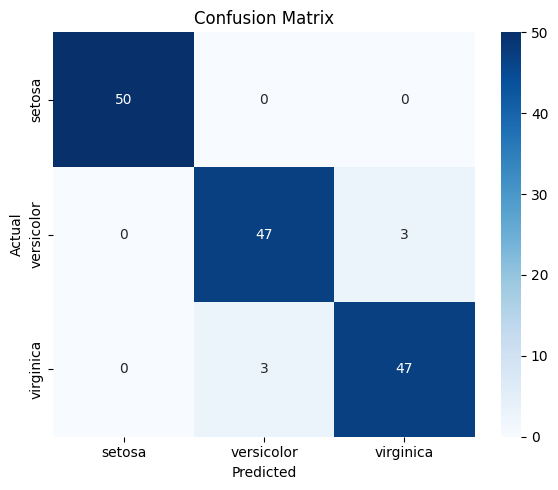

Model saved → /workspaces/DATA_SCIENCE-ELTE-/Deep Neural Network Class_ SEMI/Deep Neural Network/models/mlp_iris.pkl


In [36]:
# Classification Report — on TEST data only to avoid data leakage and provide a realistic evaluation of the model's performance on unseen data. By using only the test set labels and predictions, we can ensure that the classification report reflects the model's ability to generalize to new, unseen data, which is crucial for assessing its real-world performance.
print("\nClassification Report:")
print(classification_report(all_y_test, all_y_pred,
      target_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']))

# Confusion Matrix
cm = confusion_matrix(all_y_test, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(REPORTS / 'confusion_matrix.png')
plt.show()

# Save Model
joblib.dump(model, MODELS / 'mlp_iris.pkl')
print(f"Model saved → {MODELS / 'mlp_iris.pkl'}")



